# 11 — Portfolio Risk

**Chain position:** … → Forensics → Crowding → Construction → `Risk`

Notebook 10 produced a book. This one asks what it can lose.

### One code path, several weight vectors

Every function here takes a **weights vector**, so the model book, the lot-quantised book
and a real book from `data/portfolio.csv` are the same code with different inputs. Nothing
in `mkt.risk` knows or cares which it was handed.

That is used immediately: the target book and the lot-quantised realised book are run side
by side, which turns notebook 10's tracking error from a weight table into a risk number.

### What is measured honestly here, and what is not

The fixed-weight return series below is built from **today's** names over the **past** two
years. Those names were selected using data through today, so:

- **Risk measures are legitimate.** Volatility, VaR, CVaR, beta, risk contribution and
  concentration describe the dispersion of the stated book. Selection biases these only
  mildly — a portfolio of large-cap Indian equities has roughly the risk profile of
  large-cap Indian equities however you picked it.
- **Return measures are not.** Alpha, Sharpe and CAGR over that window are hindsight. They
  are printed once, in section 7, under a heading that says so, and never used as evidence.

This is trap #4 wearing different clothes: the moment a *selected* set of names is run
backwards through history, the result flatters itself.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_root = Path.cwd()
while not (_root / "mkt").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mkt
from mkt import (config, cache, fetch, align, dashboard, risk as rk,
                 portfolio as pf, backtest as bt, indicators as ind, viz)

REFRESH = False
mkt.bootstrap(refresh=REFRESH)

book_path = config.OUTPUT_DIR / "portfolio_book.csv"
if not book_path.exists():
    raise FileNotFoundError(f"{book_path} not found -- run notebook 10 first.")
book = pd.read_csv(book_path, index_col=0)
CAPITAL = dashboard.read().get("10_portfolio", {}).get("capital_INR", config.DEFAULT_CAPITAL)

books = {
    "target": book["target_weight"],
    "realised": book["realised_weight"],
}
real = pf.load_book()
if real is not None:
    books["real (data/portfolio.csv)"] = real
    print(f"real book found: {len(real)} positions from {config.PORTFOLIO_CSV}")
else:
    print(f"{config.PORTFOLIO_CSV} not present -- running on the model book only.")
    print("   Drop a `ticker,weight` (or `ticker,shares,price`) CSV there and re-run to")
    print("   compare what the model says you should hold against what you do hold.")

print(f"\ncapital INR {CAPITAL:,.0f}")
for name, w in books.items():
    print(f"  {name:26s} {len(w[w != 0]):2d} positions   gross {w.abs().sum():.3f}x   "
          f"net {w.sum():+.3f}x")

mkt v1.0.0 | run 2026-09-09 10:51 | REFRESH=False | cache=G:\stock market analysis\data\cache
G:\stock market analysis\data\portfolio.csv not present -- running on the model book only.
   Drop a `ticker,weight` (or `ticker,shares,price`) CSV there and re-run to
   compare what the model says you should hold against what you do hold.

capital INR 10,000,000
  target                     11 positions   gross 1.000x   net -0.082x
  realised                   11 positions   gross 0.979x   net -0.061x


## 1. Returns and covariance

Two panels, deliberately. A **recent** panel (2 years) estimates the covariance the book is
actually running today, and a **long** panel (20 years) is what the crisis replay in
section 5 needs — a 2-year window contains none of the episodes in
`config.STRESS_EPISODES`.

In [2]:
names = sorted({t for w in books.values() for t in w[w != 0].index})
panel_recent, frames, failures = bt.build_panel(list(config.NIFTY_50), period="3y")
if failures:
    display(pd.DataFrame(failures, columns=["ticker", "reason"]))

rets_all = align.to_returns(panel_recent).dropna(how="all").tail(config.COV_LOOKBACK_DAYS)
have = [t for t in names if t in rets_all.columns]
missing = [t for t in names if t not in have]
if missing:
    print(f"no recent prices for: {missing}")
rets = rets_all[have]
cov = rk.shrunk_cov(rets)

bench_px = fetch.price_history(config.BENCHMARK, period="3y", quiet=True)["Close"]
bench_rets = bench_px.pct_change().reindex(rets.index)

print(f"recent panel : {rets.shape[0]} sessions x {rets.shape[1]} names "
      f"({rets.index.min().date()} -> {rets.index.max().date()})")
print(f"covariance   : Ledoit-Wolf shrinkage {cov.attrs['shrinkage']:.3f}, "
      f"average correlation {cov.attrs['avg_correlation']:+.3f}")

long_panel, _, _ = bt.build_panel(list(config.NIFTY_50),
                                  period=config.LONG_HISTORY_PERIOD)
print(f"long panel   : {long_panel.shape[0]} sessions "
      f"({long_panel.index.min().date()} -> {long_panel.index.max().date()}) "
      f"-- for the crisis replay")

  fetched 50/50 tickers in 1s


recent panel : 504 sessions x 11 names (2024-08-29 -> 2026-09-09)
covariance   : Ledoit-Wolf shrinkage 0.300, average correlation +0.230


  fetched 50/50 tickers in 2s


long panel   : 4657 sessions (2007-09-17 -> 2026-09-09) -- for the crisis replay


## 2. Value at risk

Four measures at two confidences, for each book.

- **Historical** — the empirical quantile. No distributional assumption at all.
- **Parametric** — Gaussian, from the covariance matrix.
- **Cornish–Fisher** — Gaussian corrected for the sample's own skew and excess kurtosis.
  Equity books are left-skewed and fat-tailed, so a plain Gaussian VaR understates exactly
  the loss that matters.
- **CVaR** — the average loss *given* the VaR level is breached. The number that describes
  a bad day rather than the threshold of one.

The historical-vs-parametric gap is a **cross-check**, not a menu. The two measure the same
thing two ways: a gap of a few tenths of a point is the non-normality Cornish–Fisher then
quantifies, but a gap of several points means the covariance matrix and the return panel
describe different portfolios — a bug, not a view.

In [3]:
var_tables = {}
for name, w in books.items():
    ww = w.reindex(rets.columns).fillna(0.0)
    var_tables[name] = rk.var_table(ww, rets, cov, capital=CAPITAL)
    print(f"\n{name.upper()}  (1 trading day)")
    display(var_tables[name].round(4))

# Cross-check. 0.35pp is calibrated to this book: the observed gap is ~0.13pp, which is
# distributional. Several points would mean the panel and the covariance disagree.
for name, vt in var_tables.items():
    chk = rk.assert_var_agreement(vt, tolerance_pp=0.35, label=name)
    print(f"{name:26s} {chk['result'].iloc[0]} (max gap {chk['max_gap_pp'].iloc[0]:.3f}pp)")


TARGET  (1 trading day)


,historical_%,parametric_%,cornish_fisher_%,cvar_%,hist_vs_param_pp,historical_INR,cvar_INR
confidence,,,,,,,
0.95,0.60,0.69,0.56,0.80,-0.09,"60,414.57","79,904.49"
0.99,0.96,0.98,1.03,1.06,-0.02,"96,230.40","106,218.24"



REALISED  (1 trading day)


,historical_%,parametric_%,cornish_fisher_%,cvar_%,hist_vs_param_pp,historical_INR,cvar_INR
confidence,,,,,,,
0.95,0.60,0.67,0.59,0.80,-0.07,"59,759.71","79,870.98"
0.99,0.93,0.94,0.95,1.08,-0.01,"93,104.20","108,191.33"


target                     historical and parametric VaR agree (max gap 0.089pp)
realised                   historical and parametric VaR agree (max gap 0.069pp)


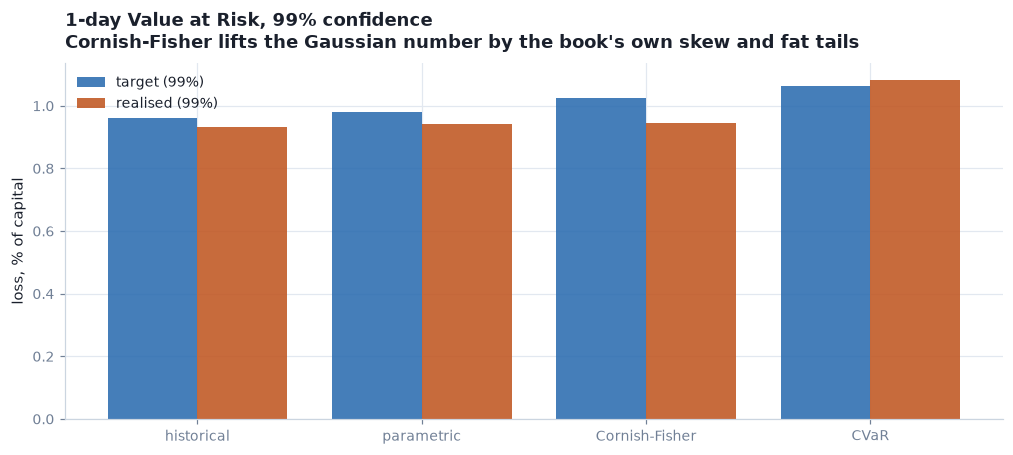

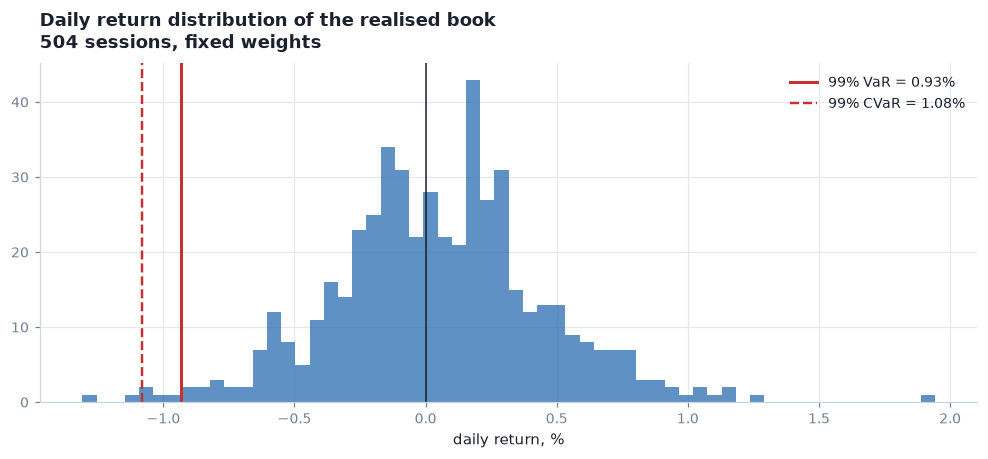

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.2))
methods = ["historical_%", "parametric_%", "cornish_fisher_%", "cvar_%"]
labels = ["historical", "parametric", "Cornish-Fisher", "CVaR"]
x = np.arange(len(methods))
width = 0.8 / len(var_tables)
for i, (name, vt) in enumerate(var_tables.items()):
    ax.bar(x + (i - (len(var_tables) - 1) / 2) * width,
           [vt.loc[0.99, m] for m in methods], width,
           label=f"{name} (99%)", color=viz.PALETTE[i], alpha=0.88)
ax.set_xticks(x); ax.set_xticklabels(labels)
viz.title(ax, "1-day Value at Risk, 99% confidence",
          "Cornish-Fisher lifts the Gaussian number by the book's own skew and fat tails")
ax.set_ylabel("loss, % of capital"); ax.legend()
viz.save(fig, "11_var_methods"); plt.show()

pr_target = rk.portfolio_returns(books["target"].reindex(rets.columns).fillna(0.0), rets)
pr_real = rk.portfolio_returns(books["realised"].reindex(rets.columns).fillna(0.0), rets)
v99 = var_tables["realised"].loc[0.99, "historical_%"]
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(pr_real * 100, bins=60, color=viz.PALETTE[0], alpha=0.75)
ax.axvline(-v99, color=viz.NEG, lw=2, label=f"99% VaR = {v99:.2f}%")
ax.axvline(-var_tables["realised"].loc[0.99, "cvar_%"], color=viz.NEG, ls="--", lw=1.6,
           label=f"99% CVaR = {var_tables['realised'].loc[0.99, 'cvar_%']:.2f}%")
ax.axvline(0, color=viz.INK, lw=1)
viz.title(ax, "Daily return distribution of the realised book",
          f"{len(pr_real)} sessions, fixed weights")
ax.set_xlabel("daily return, %"); ax.legend()
viz.save(fig, "11_return_distribution"); plt.show()

## 3. Beta: is it actually market-neutral?

Beta-matched sizing is a claim. This is the test.

In [5]:
rows = []
for name, w in books.items():
    ww = w.reindex(rets.columns).fillna(0.0)
    pr = rk.portfolio_returns(ww, rets)
    b = rk.portfolio_beta(pr, bench_rets)
    rows.append({"book": name, **b, "gross": ww.abs().sum(), "net": ww.sum()})
beta_tbl = pd.DataFrame(rows).set_index("book")
display(beta_tbl.round(4))

b_real = beta_tbl.loc["realised", "beta"]
r2_real = beta_tbl.loc["realised", "r2"]
print(f"Realised book beta to {config.BENCHMARK}: {b_real:+.3f} with R-squared {r2_real:.3f}.")
print(f"An R-squared of {r2_real:.1%} means the Nifty explains almost none of this book's")
print("variation -- which is what market-neutral is supposed to mean, and is a stronger")
print("statement than the beta alone. A beta near zero with a high R-squared would mean")
print("the market is being tracked and then cancelled, not avoided.")
print(f"\nNote the net exposure is {beta_tbl.loc['realised', 'net']:+.3f}x, not zero: the legs")
print("are matched on beta, not on rupees. The short book has the lower beta, so it needs")
print("more notional to offset the long book -- dollar neutrality would have left market")
print("exposure behind.")

,beta,alpha_ann_%,r2,n,gross,net
book,,,,,,
target,0.01,13.85,0.00,504,1.00,-0.08
realised,0.05,12.72,0.01,504,0.98,-0.06


Realised book beta to ^NSEI: +0.045 with R-squared 0.008.
An R-squared of 0.8% means the Nifty explains almost none of this book's
variation -- which is what market-neutral is supposed to mean, and is a stronger
statement than the beta alone. A beta near zero with a high R-squared would mean
the market is being tracked and then cancelled, not avoided.

Note the net exposure is -0.061x, not zero: the legs
are matched on beta, not on rupees. The short book has the lower beta, so it needs
more notional to offset the long book -- dollar neutrality would have left market
exposure behind.


## 4. Where does the risk actually come from?

Component contributions sum exactly to total volatility, which is what makes the percentage
column meaningful. The name that drives the variance is rarely the largest weight — it is
the one whose covariance with everything else is highest.

,weight,weight_%_of_gross,marginal_%,component_%,pct_of_risk
DRREDDY.NS,-0.14,14.57,-9.36,1.34,20.76
TATACONSUM.NS,-0.11,11.32,-9.04,1.00,15.57
HINDUNILVR.NS,-0.12,11.98,-7.17,0.84,13.07
WIPRO.NS,-0.10,10.31,-8.29,0.84,13.00
TMPV.NS,-0.05,4.94,-9.86,0.48,7.42
COALINDIA.NS,0.09,8.76,5.00,0.43,6.67
ICICIBANK.NS,0.09,9.55,3.71,0.35,5.38
KOTAKBANK.NS,0.08,7.97,4.17,0.33,5.06
ADANIPORTS.NS,0.06,5.61,5.85,0.32,5.00
JSWSTEEL.NS,0.07,6.90,4.03,0.27,4.23


portfolio vol 6.44% (component contributions sum to 6.44% -- exact by construction)

largest weight       : DRREDDY (14.6% of gross, 20.8% of risk)
largest risk source  : DRREDDY (14.6% of gross, 20.8% of risk)

the short leg is 53% of gross exposure but 70% of risk


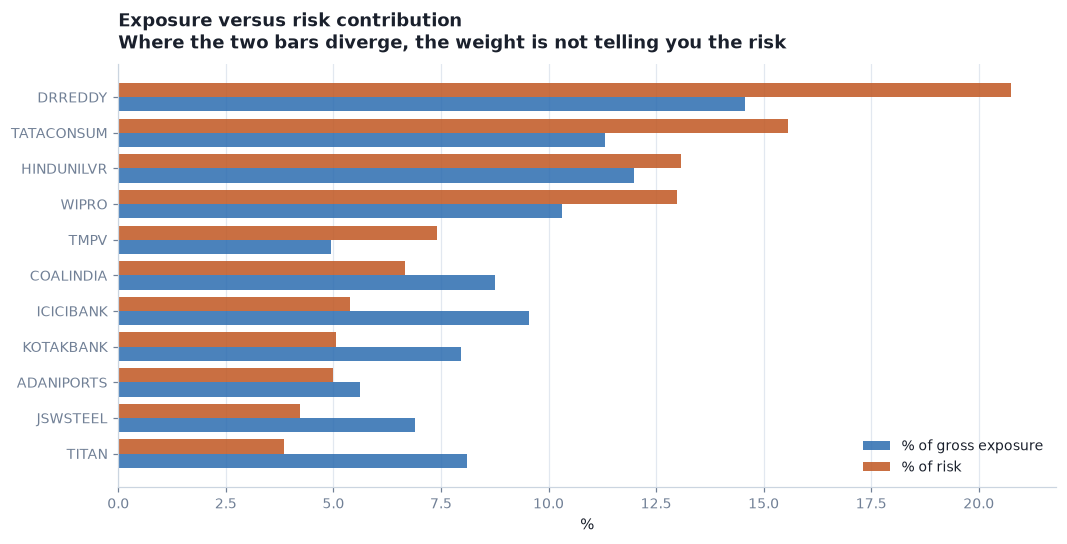

In [6]:
w_real = books["realised"].reindex(rets.columns).fillna(0.0)
rc = rk.risk_contribution(w_real, cov)
display(rc.round(3))

print(f"portfolio vol {rc.attrs['portfolio_vol_%']:.2f}% "
      f"(component contributions sum to {rc.attrs['sum_check']:.2f}% -- exact by construction)")

top_risk = rc.index[0]
top_weight = rc["weight"].abs().idxmax()
print(f"\nlargest weight       : {top_weight.replace('.NS', '')} "
      f"({rc.loc[top_weight, 'weight_%_of_gross']:.1f}% of gross, "
      f"{rc.loc[top_weight, 'pct_of_risk']:.1f}% of risk)")
print(f"largest risk source  : {top_risk.replace('.NS', '')} "
      f"({rc.loc[top_risk, 'weight_%_of_gross']:.1f}% of gross, "
      f"{rc.loc[top_risk, 'pct_of_risk']:.1f}% of risk)")
if top_risk != top_weight:
    print("   They are different names. That gap is the whole reason to compute this.")

short_risk = rc.loc[rc["weight"] < 0, "pct_of_risk"].sum()
print(f"\nthe short leg is {abs(w_real[w_real < 0].sum()) / w_real.abs().sum() * 100:.0f}% of "
      f"gross exposure but {short_risk:.0f}% of risk")

fig, ax = plt.subplots(figsize=(11, 5))
order = rc.sort_values("pct_of_risk")
y = np.arange(len(order))
ax.barh(y - 0.2, order["weight_%_of_gross"], 0.4, label="% of gross exposure",
        color=viz.PALETTE[0], alpha=0.85)
ax.barh(y + 0.2, order["pct_of_risk"], 0.4, label="% of risk",
        color=viz.PALETTE[1], alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels([t.replace(".NS", "") for t in order.index], fontsize=9)
ax.grid(axis="y", visible=False)
viz.title(ax, "Exposure versus risk contribution",
          "Where the two bars diverge, the weight is not telling you the risk")
ax.set_xlabel("%"); ax.legend()
viz.save(fig, "11_risk_contribution"); plt.show()

,value
n_assets,11.00
pc1_variance_%,30.36
pc3_variance_%,48.76
effective_bets_entropy,9.06
effective_bets_herfindahl,7.01
avg_correlation,0.23
effective_positions,10.10


The leading principal component explains 30% of the cross-sectional variance of these 11 names,
and the book holds about 9.1 effective independent bets against 10.1 effective positions.
A book of eleven names driven by one factor is one bet wearing eleven names.


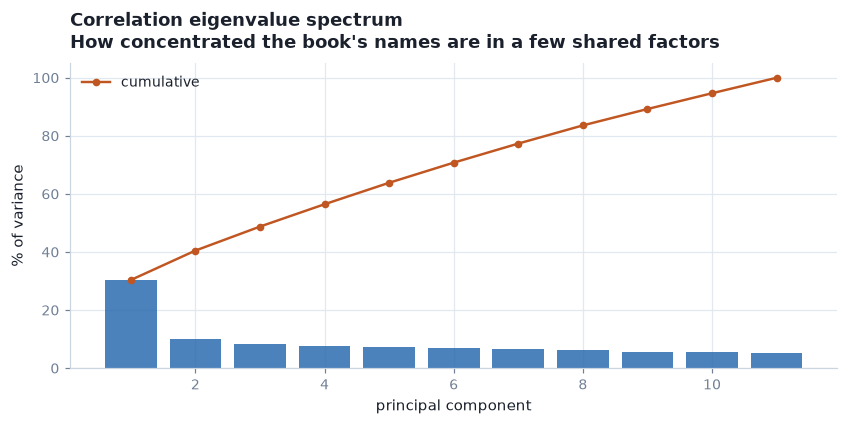

In [7]:
conc = rk.concentration(cov, w_real)
display(pd.Series({k: v for k, v in conc.items() if k != "eigenvalues"}).to_frame("value").round(3))

print(f"The leading principal component explains {conc['pc1_variance_%']:.0f}% of the "
      f"cross-sectional variance of these {conc['n_assets']} names,")
print(f"and the book holds about {conc['effective_bets_entropy']:.1f} effective independent "
      f"bets against {conc['effective_positions']:.1f} effective positions.")
print("A book of eleven names driven by one factor is one bet wearing eleven names.")

fig, ax = plt.subplots(figsize=(9, 3.6))
ev = conc["eigenvalues"]
ax.bar(range(1, len(ev) + 1), ev / ev.sum() * 100, color=viz.PALETTE[0], alpha=0.85)
ax.plot(range(1, len(ev) + 1), np.cumsum(ev) / ev.sum() * 100, color=viz.PALETTE[1],
        marker="o", ms=4, lw=1.6, label="cumulative")
viz.title(ax, "Correlation eigenvalue spectrum",
          "How concentrated the book's names are in a few shared factors")
ax.set_xlabel("principal component"); ax.set_ylabel("% of variance"); ax.legend()
viz.save(fig, "11_eigenvalues"); plt.show()

## 5. Crisis replay

Today's weights, actual prices, real dated episodes from `config.STRESS_EPISODES`. Not a
simulated shock — what a book shaped like this one would have done through events that
happened.

Coverage is reported per episode rather than quietly dropping the ones the price history
does not reach. `names_covered` matters: an episode in which only half the book was listed
is a partial answer, and it says so.

**One caveat the coverage count cannot express.** Yahoo maps a demerged entity onto its
predecessor's price series, so `TMPV.NS` — the Tata Motors passenger-vehicle company
created by the 2025 demerger — carries prices back to 2006. Those pre-2025 observations are
*combined* Tata Motors, not the demerged business. The replay therefore treats a name as
having history it did not have as a separate company. The cell below prints each name's
first observation so this is visible rather than inferred.

In [8]:
depth = pd.DataFrame({
    "first_obs": {t: long_panel[t].first_valid_index() for t in w_real[w_real != 0].index
                  if t in long_panel.columns},
    "sessions": {t: int(long_panel[t].notna().sum()) for t in w_real[w_real != 0].index
                 if t in long_panel.columns},
}).sort_values("first_obs")
depth["weight"] = w_real.reindex(depth.index)
display(depth)
young = depth[depth["first_obs"] > pd.Timestamp("2015-01-01")]
if len(young):
    print(f"{len(young)} name(s) listed after 2015 -- earlier episodes cannot include them.")
else:
    print("Every name in the book has price history reaching back before 2015,")
    print("including at least one that owes that history to a predecessor entity.")

,first_obs,sessions,weight
DRREDDY.NS,2007-09-17,4657,-0.14
HINDUNILVR.NS,2007-09-17,4657,-0.12
ICICIBANK.NS,2007-09-17,4657,0.09
JSWSTEEL.NS,2007-09-17,4657,0.07
KOTAKBANK.NS,2007-09-17,4657,0.08
TATACONSUM.NS,2007-09-17,4657,-0.11
TITAN.NS,2007-09-17,4657,0.08
TMPV.NS,2007-09-17,4657,-0.05
WIPRO.NS,2007-09-17,4657,-0.10
ADANIPORTS.NS,2007-11-27,4608,0.05


Every name in the book has price history reaching back before 2015,
including at least one that owes that history to a predecessor entity.


,start,end,sessions,names_covered,names_in_book,book_return_%,scaled_to_full_gross_%,worst_name,worst_name_%,note
episode,,,,,,,,,,
GFC / Lehman,2008-09-01,2009-03-09,123,10,11,-4.56,-5.00,ICICIBANK.NS,-5.65,only 10/11 names listed
Taper tantrum,2013-05-22,2013-09-04,74,11,11,-16.82,-16.82,WIPRO.NS,-4.11,
2018 tightening,2018-10-01,2018-12-24,57,11,11,1.16,1.16,JSWSTEEL.NS,-1.57,
COVID crash,2020-02-19,2020-03-23,22,11,11,-3.62,-3.62,ICICIBANK.NS,-4.48,
Inflation shock,2021-11-01,2022-06-16,156,11,11,3.43,3.43,KOTAKBANK.NS,-1.51,
Hiking cycle / SVB,2023-03-08,2023-03-20,9,11,11,0.00,0.00,ICICIBANK.NS,-0.38,


episodes with usable history: 6/6

worst episode for this book: Taper tantrum (-16.8% scaled to full gross, 11/11 names listed)
   worst single name there: WIPRO contributing -4.1%


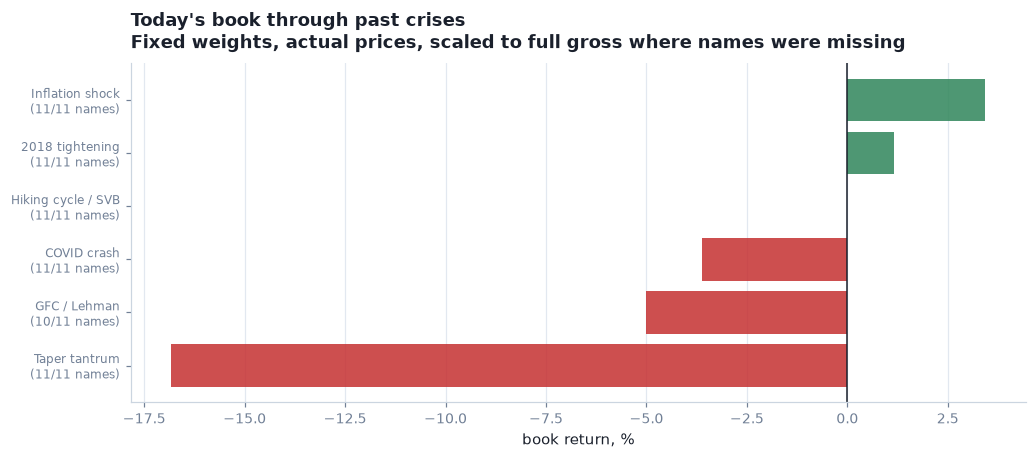

In [9]:
replay = rk.replay_episodes(w_real, long_panel)
display(replay.round(2))
print(f"episodes with usable history: {replay.attrs['episodes_covered']}"
      f"/{replay.attrs['episodes_total']}")

covered = replay.dropna(subset=["book_return_%"])
if len(covered):
    worst = covered["scaled_to_full_gross_%"].idxmin()
    print(f"\nworst episode for this book: {worst} "
          f"({covered.loc[worst, 'scaled_to_full_gross_%']:+.1f}% scaled to full gross, "
          f"{int(covered.loc[worst, 'names_covered'])}/"
          f"{int(covered.loc[worst, 'names_in_book'])} names listed)")
    print(f"   worst single name there: {covered.loc[worst, 'worst_name'].replace('.NS', '')} "
          f"contributing {covered.loc[worst, 'worst_name_%']:+.1f}%")

    fig, ax = plt.subplots(figsize=(10.5, 4))
    vals = covered["scaled_to_full_gross_%"].sort_values()
    ax.barh(range(len(vals)), vals.values,
            color=[viz.NEG if v < 0 else viz.POS for v in vals.values], alpha=0.85)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels([f"{i}\n({int(covered.loc[i, 'names_covered'])}/"
                        f"{int(covered.loc[i, 'names_in_book'])} names)" for i in vals.index],
                       fontsize=8)
    ax.axvline(0, color=viz.INK, lw=1); ax.grid(axis="y", visible=False)
    viz.title(ax, "Today's book through past crises",
              "Fixed weights, actual prices, scaled to full gross where names were missing")
    ax.set_xlabel("book return, %")
    viz.save(fig, "11_crisis_replay"); plt.show()
else:
    print("\nNo episode is covered by the available price history.")

## 6. Forward scenarios

Factor shocks mapped through estimated betas. These are estimates on top of estimates: a
beta from a linear regression, applied to a move nobody has observed. The mean R-squared is
printed next to every scenario so the reader can discount accordingly — a beta from a
regression explaining 3% of the variance is a number, not a relationship.

factor betas estimated for 11/11 names on 504 sessions


,crude,usdinr,us_duration,world_equity,gold,dollar,alpha,r2,n_obs
ADANIPORTS.NS,-0.10,-0.47,-0.20,0.21,0.09,-0.23,0.00,0.06,503.00
COALINDIA.NS,0.05,0.11,-0.06,0.04,0.09,-0.21,-0.00,0.03,503.00
DRREDDY.NS,-0.01,-0.08,-0.13,0.06,0.00,0.03,-0.00,0.01,503.00
HINDUNILVR.NS,-0.03,-0.22,-0.12,0.03,0.04,0.14,-0.00,0.01,503.00
ICICIBANK.NS,-0.07,-0.31,-0.06,0.05,0.04,0.01,0.00,0.05,503.00
JSWSTEEL.NS,-0.01,-0.54,-0.06,0.06,0.20,-0.10,0.00,0.07,503.00
KOTAKBANK.NS,-0.04,-0.37,-0.01,0.06,0.12,-0.09,0.00,0.04,503.00
TATACONSUM.NS,-0.02,-0.27,-0.01,0.04,0.03,0.02,-0.00,0.01,503.00
TITAN.NS,-0.06,-0.25,-0.05,0.09,0.15,0.17,0.00,0.05,503.00
TMPV.NS,-0.12,-0.24,-0.26,0.35,0.05,-0.16,-0.00,0.04,503.00


,book_return_%,factors,mean_r2,worst_name,worst_name_%,best_name,best_name_%,book_INR
scenario,,,,,,,,
Crude +30%,-0.02,crude +30%,0.04,ICICIBANK.NS,-0.20,TMPV.NS,0.17,"-2,157.16"
USDINR +5%,-0.15,usdinr +5%,0.04,JSWSTEEL.NS,-0.18,TATACONSUM.NS,0.15,"-14,668.96"
US10Y +100bp,-0.61,us_duration -17%,0.04,WIPRO.NS,-0.36,ADANIPORTS.NS,0.19,"-60,640.14"
Global risk-off,0.14,"world_equity -10%, gold +5%, dollar +3%, us_du...",0.04,ADANIPORTS.NS,-0.17,TMPV.NS,0.23,"13,728.48"


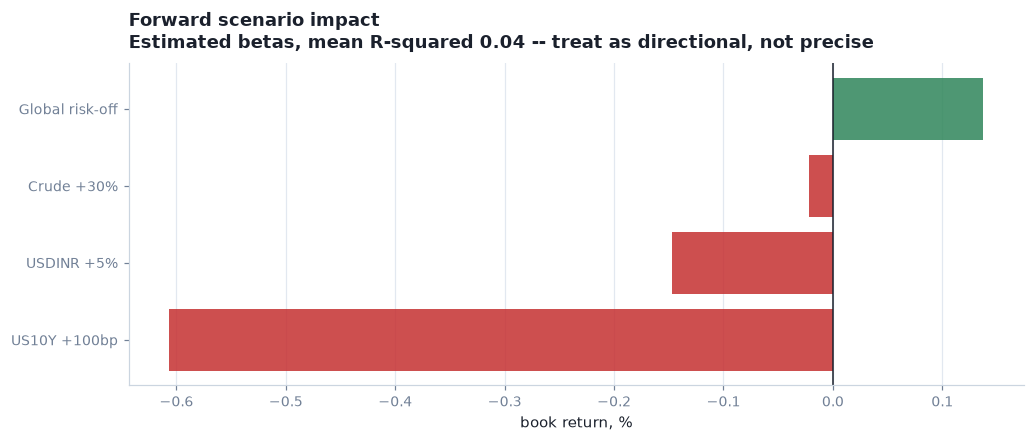

Mean regression R-squared across names: 0.037. These factors explain 4% of daily variation, so the
scenario numbers carry the sign and the rough order of magnitude, not more.


In [10]:
fac = rk.factor_returns(period="3y")
if fac.empty:
    print("no scenario factors available")
    scen = pd.DataFrame()
else:
    fac = fac.reindex(rets.index).dropna(how="all")
    betas_f = rk.factor_betas(rets, fac)
    print(f"factor betas estimated for {len(betas_f)}/{len(rets.columns)} names on "
          f"{len(fac)} sessions")
    display(betas_f.round(3))

    scen = rk.scenario_shock(w_real, betas_f, capital=CAPITAL)
    display(scen.round(3))

    if len(scen):
        fig, ax = plt.subplots(figsize=(10.5, 3.8))
        vals = scen["book_return_%"].dropna().sort_values()
        ax.barh(range(len(vals)), vals.values,
                color=[viz.NEG if v < 0 else viz.POS for v in vals.values], alpha=0.85)
        ax.set_yticks(range(len(vals)))
        ax.set_yticklabels(list(vals.index), fontsize=9)
        ax.axvline(0, color=viz.INK, lw=1); ax.grid(axis="y", visible=False)
        viz.title(ax, "Forward scenario impact",
                  f"Estimated betas, mean R-squared {scen['mean_r2'].mean():.2f} "
                  f"-- treat as directional, not precise")
        ax.set_xlabel("book return, %")
        viz.save(fig, "11_scenarios"); plt.show()
        print(f"Mean regression R-squared across names: {betas_f['r2'].mean():.3f}. "
              f"These factors explain {betas_f['r2'].mean():.0%} of daily variation, so the")
        print("scenario numbers carry the sign and the rough order of magnitude, not more.")

## 7. Realised risk over the sample — and why the return half is not evidence

The volatility, drawdown *shape* and tail statistics below describe the stated book
honestly. The **return, alpha and Sharpe do not**: these names were selected using data
through today, then run backwards through the same window. That is hindsight, and it is the
same look-ahead problem notebook 07 documented as trap #4, appearing here in a different
place.

They are printed because omitting them invites someone to compute them believing they mean
something.

RISK MEASURES -- these describe the book honestly


,target,realised
n_days,504.00,504.00
ann_vol_%,6.67,6.45
max_drawdown_%,-4.69,-4.96
current_drawdown_%,0.00,0.00
worst_day_%,-1.19,-1.31
best_day_%,2.67,1.94
skew,0.46,0.17
excess_kurtosis,2.82,1.10



RETURN MEASURES -- HINDSIGHT, NOT A BACKTEST
   Today's names run through the past. Selection makes these meaningless as
   performance. Notebook 07 is where a return claim would have to be earned.


,target,realised
ann_return_%,14.57,13.21
sharpe,2.18,2.05



Lot rounding moved realised volatility from 6.67% to 6.45% (-0.22pp).
That is notebook 10's tracking error expressed as risk rather than as weights --
the reason this notebook runs on realised weights rather than target weights.


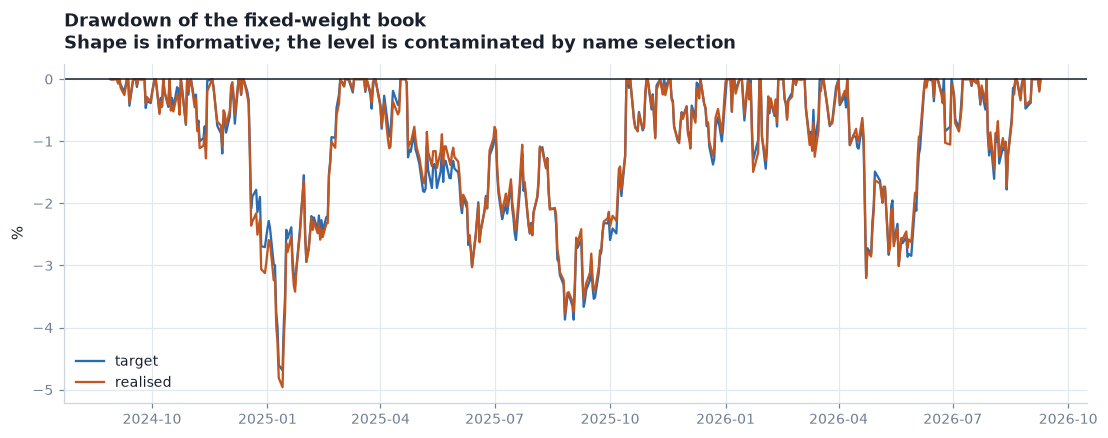

In [11]:
summ = {}
for name in ("target", "realised"):
    ww = books[name].reindex(rets.columns).fillna(0.0)
    summ[name] = rk.drawdown_summary(rk.portfolio_returns(ww, rets))
ds = pd.DataFrame(summ)

risk_rows = ["n_days", "ann_vol_%", "max_drawdown_%", "current_drawdown_%",
             "worst_day_%", "best_day_%", "skew", "excess_kurtosis"]
ret_rows = ["ann_return_%", "sharpe"]

print("RISK MEASURES -- these describe the book honestly")
display(ds.loc[risk_rows].round(3))
print("\nRETURN MEASURES -- HINDSIGHT, NOT A BACKTEST")
print("   Today's names run through the past. Selection makes these meaningless as")
print("   performance. Notebook 07 is where a return claim would have to be earned.")
display(ds.loc[ret_rows].round(3))

d_target, d_real = ds.loc["ann_vol_%", "target"], ds.loc["ann_vol_%", "realised"]
print(f"\nLot rounding moved realised volatility from {d_target:.2f}% to {d_real:.2f}% "
      f"({d_real - d_target:+.2f}pp).")
print("That is notebook 10's tracking error expressed as risk rather than as weights --")
print("the reason this notebook runs on realised weights rather than target weights.")

fig, ax = plt.subplots(figsize=(12, 4))
for i, name in enumerate(("target", "realised")):
    ww = books[name].reindex(rets.columns).fillna(0.0)
    eq = (1 + rk.portfolio_returns(ww, rets)).cumprod()
    ax.plot(eq.index, ind.drawdown(eq), lw=1.5, color=viz.PALETTE[i], label=name)
ax.axhline(0, color=viz.INK, lw=1)
viz.title(ax, "Drawdown of the fixed-weight book",
          "Shape is informative; the level is contaminated by name selection")
ax.set_ylabel("%"); ax.legend()
viz.save(fig, "11_drawdown"); plt.show()

## 8. Model book versus real book

If `data/portfolio.csv` exists, this is the gap table: what the model says you should hold
against what you do hold, and the turnover required to close it.

In [12]:
if real is not None:
    gap = pf.gap_table(books["realised"], real)
    display(gap.round(4))
    print(f"turnover to align: {gap.attrs['turnover_to_align']:.1%} of gross")
    adds = gap[gap["action"] == "add"]
    reduces = gap[gap["action"] == "reduce"]
    print(f"   add/increase : {len(adds)} names")
    print(f"   reduce/exit  : {len(reduces)} names")
else:
    gap = None
    print("No real book to compare against.")
    print("\nThe comparison path is still exercised above: `target` and `realised` are two")
    print("different weight vectors through the identical functions, which is the same")
    print("mechanism a real book would use. Dropping a `ticker,weight` CSV at")
    print(f"{config.PORTFOLIO_CSV} adds a third column to every table in this notebook.")

No real book to compare against.

The comparison path is still exercised above: `target` and `realised` are two
different weight vectors through the identical functions, which is the same
mechanism a real book would use. Dropping a `ticker,weight` CSV at
G:\stock market analysis\data\portfolio.csv adds a third column to every table in this notebook.


In [13]:
vt = var_tables["realised"]
payload = {
    "signal": (f"1d VaR99 {vt.loc[0.99, 'historical_%']:.2f}%, "
               f"CVaR99 {vt.loc[0.99, 'cvar_%']:.2f}%, beta {b_real:+.2f}"),
    "score": round(float(vt.loc[0.99, "historical_%"]), 3),
    "as_of": str(rets.index.max().date()),
    "capital_INR": CAPITAL,
    "books_evaluated": list(books),
    "var": {str(c): {"historical_%": round(float(vt.loc[c, "historical_%"]), 3),
                     "parametric_%": round(float(vt.loc[c, "parametric_%"]), 3),
                     "cornish_fisher_%": round(float(vt.loc[c, "cornish_fisher_%"]), 3),
                     "cvar_%": round(float(vt.loc[c, "cvar_%"]), 3),
                     "historical_INR": round(float(vt.loc[c, "historical_INR"]), 0)}
            for c in vt.index},
    "beta": {"beta": round(float(b_real), 4), "r2": round(float(r2_real), 4),
             "benchmark": config.BENCHMARK},
    "ann_vol_%": {"target": round(float(d_target), 2), "realised": round(float(d_real), 2)},
    "risk_contribution_top3": {t: round(float(r), 1)
                               for t, r in rc["pct_of_risk"].head(3).items()},
    "largest_weight": str(top_weight),
    "largest_risk_source": str(top_risk),
    "concentration": {k: (round(float(v), 3) if isinstance(v, (int, float)) else v)
                      for k, v in conc.items() if k != "eigenvalues"},
    "crisis_replay": {str(i): (None if not np.isfinite(r) else round(float(r), 2))
                      for i, r in replay["scaled_to_full_gross_%"].items()},
    "episodes_covered": f"{replay.attrs['episodes_covered']}/{replay.attrs['episodes_total']}",
    "scenarios": ({str(i): round(float(r), 2) for i, r in scen["book_return_%"].items()}
                  if len(scen) else {}),
    "scenario_mean_r2": (round(float(scen["mean_r2"].mean()), 3) if len(scen) else None),
    "real_book_gap_turnover": (None if gap is None
                               else round(float(gap.attrs["turnover_to_align"]), 4)),
    "caveat": ("return, alpha and Sharpe over the sample are hindsight -- today's names "
               "run backwards through the window they were selected in"),
}
dashboard.append("11_portfolio_risk", payload)
display(dashboard.summary())

,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.10,2026-09-08,2026-09-09 05:16:16
2,03_rates,Cautious on duration,-0.27,2026-09-08,2026-09-09 05:16:41
3,04_global_equity,India lagging the world,-39.12,2026-09-09,2026-09-09 05:17:20
4,05_india_market,Mixed,0.23,2026-09-09 10:41:00,2026-09-09 05:18:10
5,06_india_companies,"Top 8 of 50 screened, 6 sectors",80.75,2026-09-09,2026-09-09 05:19:06
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 05:20:08
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 05:20:28
8,09_positioning,"12 names scored, 6 short candidates checked fo...",60.19,2026-09-09,2026-09-09 05:20:53
9,10_portfolio,"6L / 5S, gross 0.98x, net -0.06x",6.44,2026-09-09,2026-09-09 05:21:07


In [14]:
print("=" * 92)
print("THE FULL CHAIN")
print("=" * 92)
data = dashboard.read()
labels = [("01_macro", "Economic state"), ("02_risk", "Global risk"),
          ("03_rates", "Rates / duration"), ("04_global_equity", "Global equity"),
          ("05_india_market", "India market"), ("06_india_companies", "Companies"),
          ("07_signal_validation", "Signal validation"), ("08_earnings_quality", "Forensics"),
          ("09_positioning", "Crowding"), ("10_portfolio", "Construction"),
          ("11_portfolio_risk", "Risk")]
for key, label in labels:
    blk = data.get(key)
    if not blk:
        print(f"{label:20s} : (not run)")
        continue
    sc = blk.get("score")
    print(f"{label:20s} : {str(blk.get('signal', ''))[:56]:58s}"
          f"{'' if sc is None else f'{sc:+9.2f}'}   as of {blk.get('as_of', '')}")
print("=" * 92)
print(f"\nWHAT THIS BOOK CAN LOSE  (capital INR {CAPITAL:,.0f})")
print(f"  1-day 99% VaR      {vt.loc[0.99, 'historical_%']:5.2f}%   "
      f"INR {vt.loc[0.99, 'historical_INR']:>12,.0f}")
print(f"  1-day 99% CVaR     {vt.loc[0.99, 'cvar_%']:5.2f}%   "
      f"INR {vt.loc[0.99, 'cvar_INR']:>12,.0f}")
print(f"  annualised vol     {d_real:5.2f}%   (target {config.TARGET_PORTFOLIO_VOL_PCT}%)")
print(f"  beta to Nifty      {b_real:+5.2f}    R-squared {r2_real:.3f}")
if len(covered):
    print(f"  worst crisis       {covered['scaled_to_full_gross_%'].min():+5.1f}%   "
          f"({covered['scaled_to_full_gross_%'].idxmin()})")
if len(scen):
    ws = scen["book_return_%"].idxmin()
    print(f"  worst scenario     {scen.loc[ws, 'book_return_%']:+5.1f}%   ({ws})")
print(f"  risk concentrated  {rc['pct_of_risk'].head(3).sum():.0f}% in "
      f"{', '.join(t.replace('.NS', '') for t in rc.index[:3])}")
print("=" * 92)

THE FULL CHAIN
Economic state       : Goldilocks (growth, cooling prices) | nowcast: Mixed          +0.00   as of 2026-09-09
Global risk          : Neutral                                                       -0.10   as of 2026-09-08
Rates / duration     : Cautious on duration                                          -0.27   as of 2026-09-08
Global equity        : India lagging the world                                      -39.12   as of 2026-09-09
India market         : Mixed                                                         +0.23   as of 2026-09-09 10:41:00
Companies            : Top 8 of 50 screened, 6 sectors                              +80.75   as of 2026-09-09
Signal validation    : Technical leg: Not proven                                     -1.62   as of 2026-09-09
Forensics            : 7 do-not-own, 8 short candidates, 43 names pass              +51.32   as of 2026-03-31
Crowding             : 12 names scored, 6 short candidates checked for squeeze      +60.19   as 

## Re-running this layer

Notebooks 07–11 extend the original chain and follow the same contract: run them in order,
each reads the previous links from `outputs/dashboard.json`.

- **07** needs nothing but prices. It is the cut point that tells you whether the screen works.
- **08** reads 06's screen and writes the filtered one. All data already cached.
- **09** is the fragile link — NSE's derivatives endpoints are undocumented and change
  without notice. `portfolio.lot_table()` carries a dated static fallback so **10 runs
  without it**, and `dashboard.summary()` skips a missing section, so the chain tolerates
  its absence.
- **10** needs 08's filtered screen and short candidates, plus lot sizes from 09 or the fallback.
- **11** needs 10's book, and optionally `data/portfolio.csv`.

The honest limits, restated because they do not go away on a re-run:

- **Point-in-time fundamentals do not exist** in any keyless source. That is a ceiling on
  how much of the screen can ever be validated, not a gap to engineer around.
- **A 50-name universe is thin** for cross-sectional statistics. `config.BACKTEST_UNIVERSE`
  is one line.
- **The scenario betas are estimates**, and the crisis replay covers only the episodes the
  price history reaches.
- **Lot quantisation is a function of capital.** The same weights are untradeable at ₹10
  lakh and near-exact at ₹10 crore.

None of this is advice. It is arithmetic you re-run, and the decisions remain yours.